In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/exercise_dataset.csv")
df.head()

,ID,Exercise,Calories Burn,Dream Weight,Actual Weight,Age,Gender,Duration,Heart Rate,BMI,Weather Conditions,Exercise Intensity
0,1,Exercise 2,286.959851,91.892531,96.301115,45,Male,37,170,29.426275,Rainy,5
1,2,Exercise 7,343.453036,64.165097,61.104668,25,Male,43,142,21.286346,Rainy,5
2,3,Exercise 4,261.223465,70.846224,71.766724,20,Male,20,148,27.899592,Cloudy,4
3,4,Exercise 5,127.183858,79.477008,82.984456,33,Male,39,170,33.729552,Sunny,10
4,5,Exercise 10,416.318374,89.960226,85.643174,29,Female,34,118,23.286113,Cloudy,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  3864 non-null   int64  
 1   Exercise            3864 non-null   object 
 2   Calories Burn       3864 non-null   float64
 3   Dream Weight        3864 non-null   float64
 4   Actual Weight       3864 non-null   float64
 5   Age                 3864 non-null   int64  
 6   Gender              3864 non-null   object 
 7   Duration            3864 non-null   int64  
 8   Heart Rate          3864 non-null   int64  
 9   BMI                 3864 non-null   float64
 10  Weather Conditions  3864 non-null   object 
 11  Exercise Intensity  3864 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 362.4+ KB


In [4]:
df.describe()

,ID,Calories Burn,Dream Weight,Actual Weight,Age,Duration,Heart Rate,BMI,Exercise Intensity
count,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000,3864.000000
mean,1932.500000,301.861806,75.139263,75.188440,39.621118,40.190994,139.777950,26.801977,5.457298
std,1115.585048,115.828604,14.545824,14.845511,12.521721,11.765957,23.447528,4.746745,2.850896
min,1.000000,100.009403,50.001984,45.783747,18.000000,20.000000,100.000000,18.500014,1.000000
25%,966.750000,202.168837,62.373585,62.476906,29.000000,30.000000,119.000000,22.686774,3.000000
50%,1932.500000,299.742508,75.522136,75.544407,40.000000,40.000000,140.000000,26.861656,5.000000
75%,2898.250000,404.143688,87.707989,88.105767,51.000000,51.000000,160.000000,30.950380,8.000000
max,3864.000000,499.859262,99.985355,104.309600,60.000000,60.000000,180.000000,34.996639,10.000000


In [5]:
df.columns

Index(['ID', 'Exercise', 'Calories Burn', 'Dream Weight', 'Actual Weight',
       'Age', 'Gender', 'Duration', 'Heart Rate', 'BMI', 'Weather Conditions',
       'Exercise Intensity'],
      dtype='object')

In [6]:
fitness_df = df[["Duration", "Heart Rate", "Calories Burn"]]
fitness_df.head()

,Duration,Heart Rate,Calories Burn
0,37,170,286.959851
1,43,142,343.453036
2,20,148,261.223465
3,39,170,127.183858
4,34,118,416.318374


In [7]:
fitness_df.isnull().sum()

Duration         0
Heart Rate       0
Calories Burn    0
dtype: int64

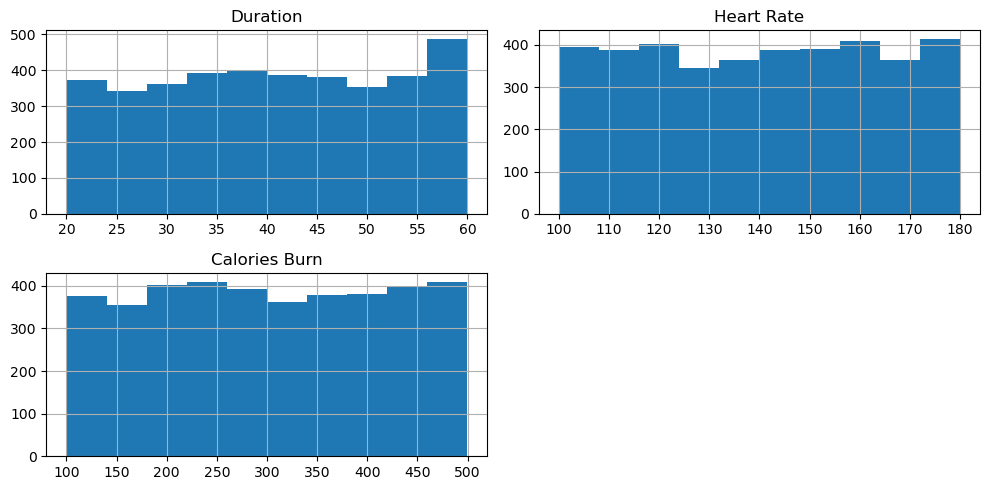

In [8]:
fitness_df.hist(figsize=(10, 5))
plt.tight_layout()
plt.show()

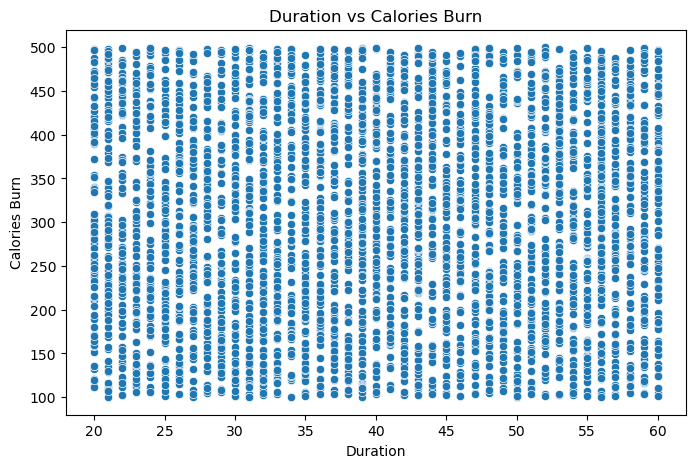

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=fitness_df, x="Duration", y="Calories Burn")
plt.title("Duration vs Calories Burn")
plt.show()

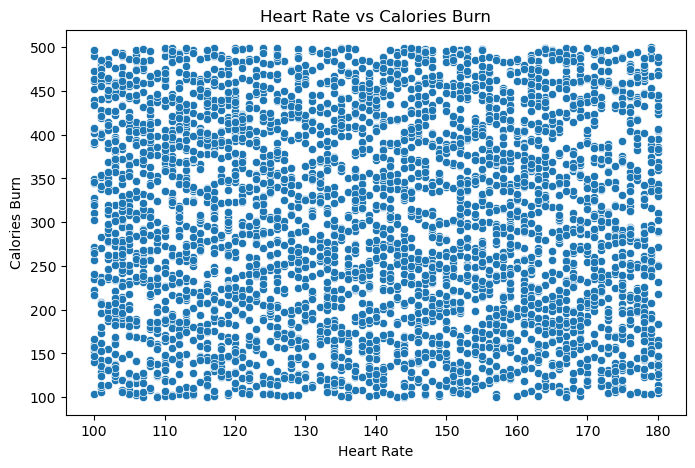

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=fitness_df, x="Heart Rate", y="Calories Burn")
plt.title("Heart Rate vs Calories Burn")
plt.show()

<Axes: xlabel='Exercise Intensity', ylabel='Calories Burn'>

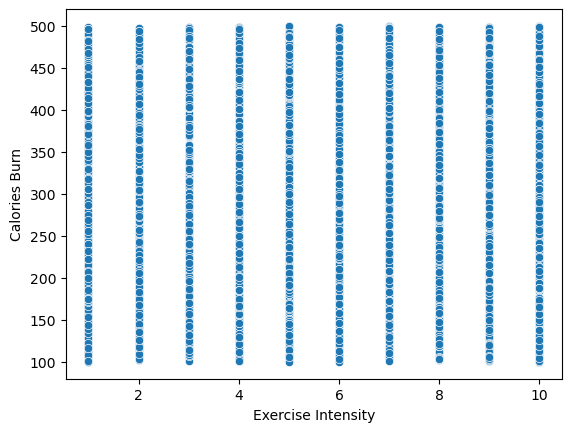

In [15]:
sns.scatterplot(data=df, x="Exercise Intensity", y="Calories Burn")

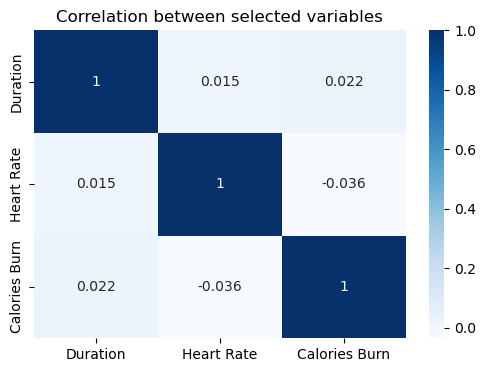

In [11]:
plt.figure(figsize=(6, 4))
sns.heatmap(fitness_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation between selected variables")
plt.show()

## Initial analysis

In this part of the project, I focus on the relationship between exercise duration, heart rate, and calories burned.

The goal is to explore whether longer workouts and higher heart rate are associated with higher calorie burn, and later use machine learning to detect unusual patterns.

In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(fitness_df)

In [13]:
scaled_df = pd.DataFrame(scaled_data, columns=fitness_df.columns)
scaled_df.head()

,Duration,Heart Rate,Calories Burn
0,-0.271241,1.289089,-0.128672
1,0.238771,0.094779,0.359122
2,-1.716274,0.350703,-0.350894
3,-0.101237,1.289089,-1.508268
4,-0.526247,-0.928915,0.988282


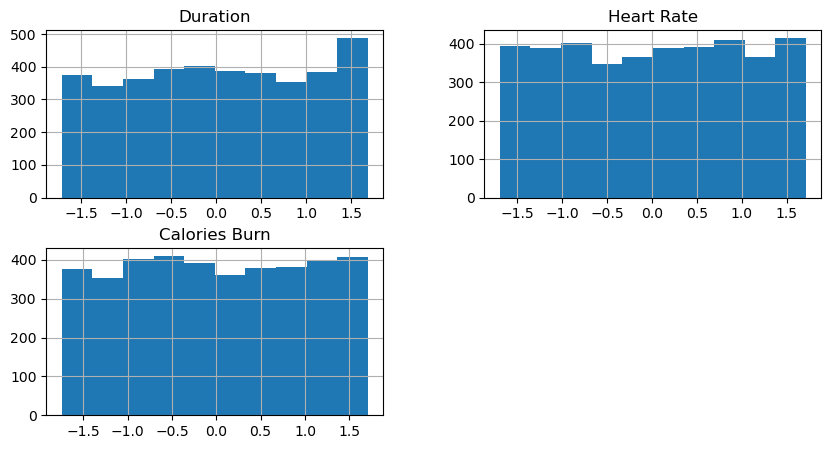

In [14]:
scaled_df.hist(figsize=(10,5))
plt.show()

## Observation

The correlation between duration, heart rate, and calories burned is very weak. This suggests that the variables are not strongly linearly related in this dataset.

This makes it interesting to apply anomaly detection, as unusual patterns may not be obvious from simple relationships.